In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [12]:
iris= load_iris()
df = pd.read_csv('/content/IRIS.csv')
df= pd.DataFrame(iris.data, columns=iris.feature_names)
df['Species'] = iris.target
df['Species_Name'] = df['Species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

In [13]:
print(f"\nIris Dataset loaded! (No upload needed — built-in dataset)")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print(f"3 Species: Setosa, Versicolor, Virginica")


Iris Dataset loaded! (No upload needed — built-in dataset)
Rows: 150  |  Columns: 6
3 Species: Setosa, Versicolor, Virginica


In [14]:
print("\nFirst 10 rows:")
print(df.head(10))
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())
print("\nSpecies Count:")
print(df['Species_Name'].value_counts())
print("→ Each species has exactly 50 samples!")
print("\nMissing Values:")
print(df.isnull().sum())
print("→ No missing values! Clean dataset.")
print("\nAverage measurements per Species:")
print(df.groupby('Species_Name')[iris.feature_names].mean().round(2))


First 10 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   Species Species_Name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0


Generating EDA charts...


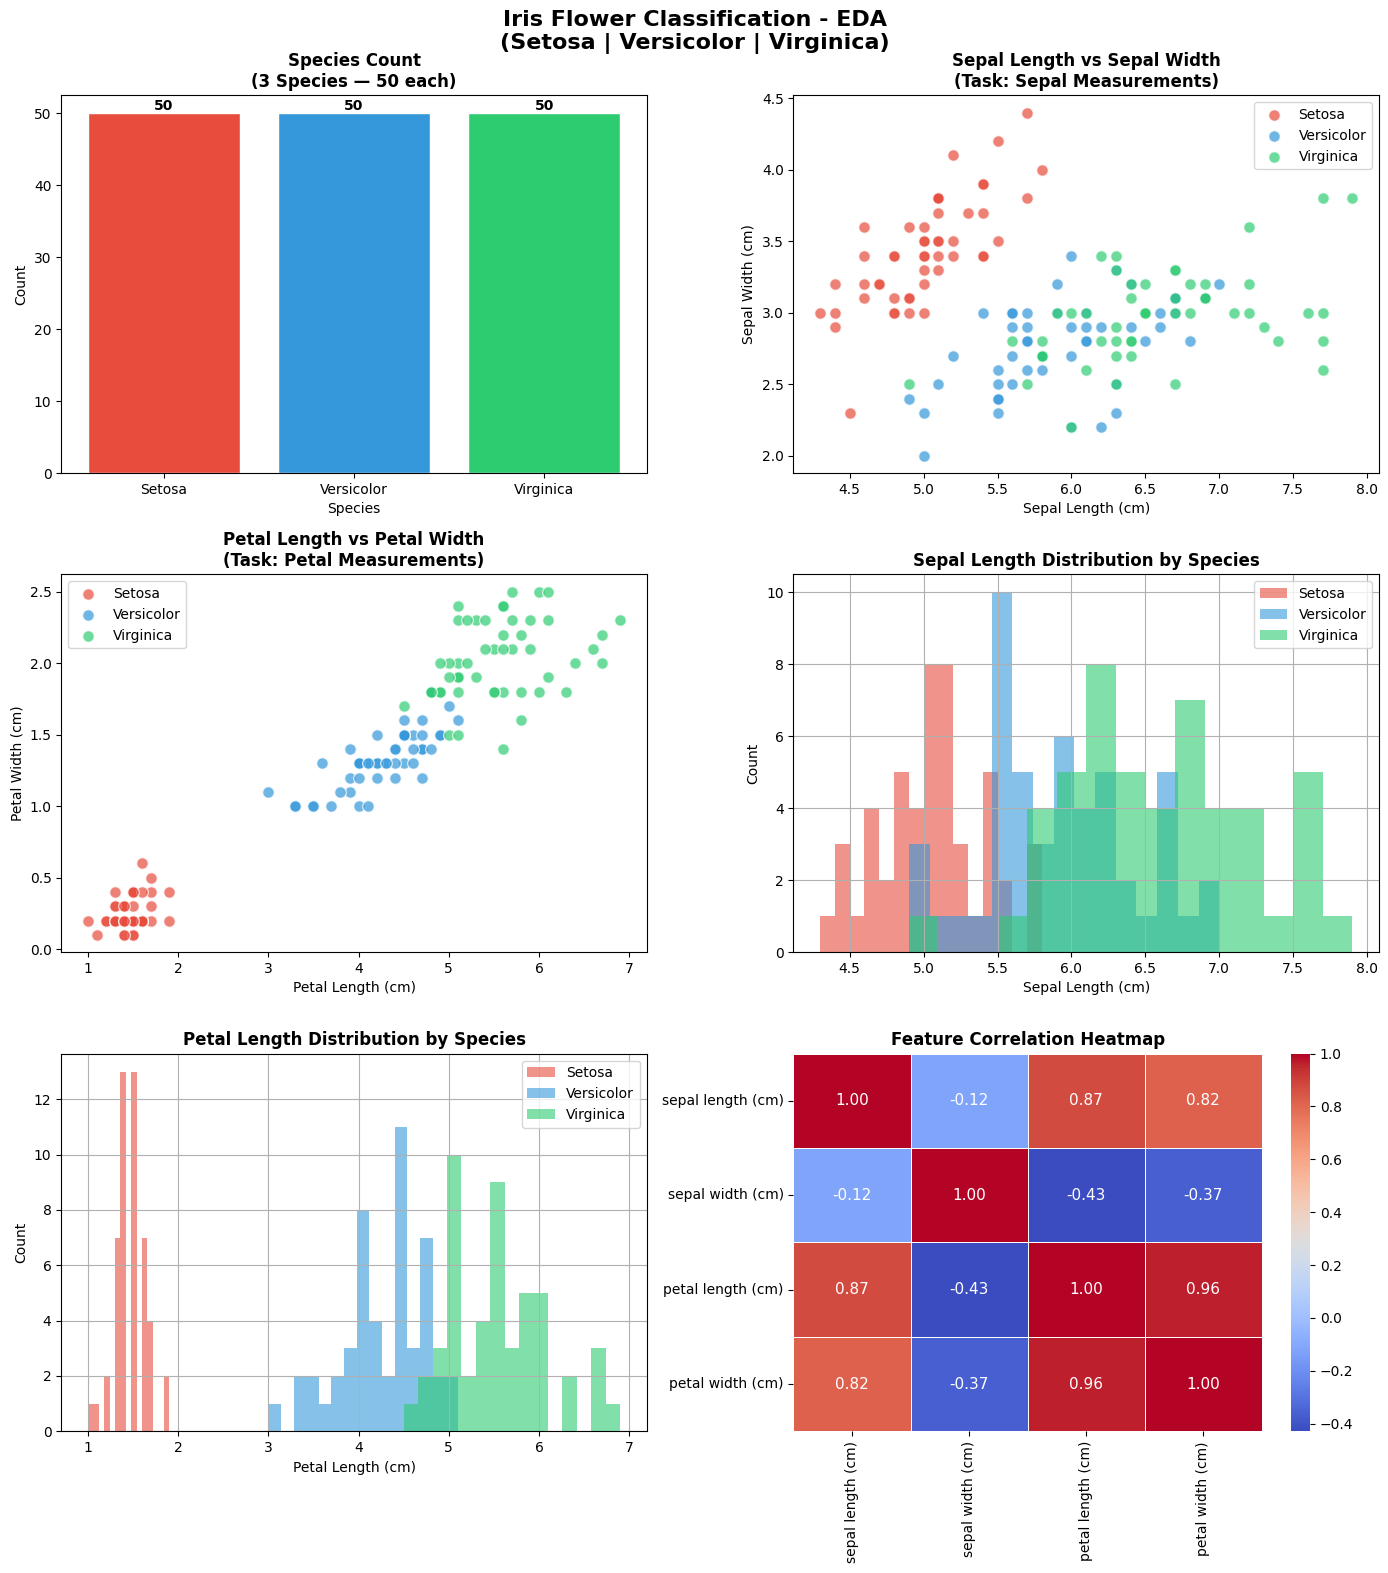

 EDA charts saved as iris_eda.png!


In [15]:
print("\nGenerating EDA charts...")

colors = {
    'Setosa'    : '#e74c3c',
    'Versicolor': '#3498db',
    'Virginica' : '#2ecc71'
}

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Iris Flower Classification - EDA\n(Setosa | Versicolor | Virginica)',
             fontsize=16, fontweight='bold')

species_counts = df['Species_Name'].value_counts()
axes[0,0].bar(species_counts.index, species_counts.values,
              color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[0,0].set_title('Species Count\n(3 Species — 50 each)', fontweight='bold')
axes[0,0].set_xlabel('Species')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(species_counts.values):
    axes[0,0].text(i, v+0.5, str(v), ha='center', fontweight='bold')
for species, color in colors.items():
    subset = df[df['Species_Name'] == species]
    axes[0,1].scatter(subset['sepal length (cm)'],
                      subset['sepal width (cm)'],
                      label=species, color=color, alpha=0.7, s=70,
                      edgecolors='white')
axes[0,1].set_title('Sepal Length vs Sepal Width\n(Task: Sepal Measurements)',
                     fontweight='bold')
axes[0,1].set_xlabel('Sepal Length (cm)')
axes[0,1].set_ylabel('Sepal Width (cm)')
axes[0,1].legend()

for species, color in colors.items():
    subset = df[df['Species_Name'] == species]
    axes[1,0].scatter(subset['petal length (cm)'],
                      subset['petal width (cm)'],
                      label=species, color=color, alpha=0.7, s=70,
                      edgecolors='white')
axes[1,0].set_title('Petal Length vs Petal Width\n(Task: Petal Measurements)',
                     fontweight='bold')
axes[1,0].set_xlabel('Petal Length (cm)')
axes[1,0].set_ylabel('Petal Width (cm)')
axes[1,0].legend()

for species, color in colors.items():
    subset = df[df['Species_Name'] == species]
    subset['sepal length (cm)'].hist(
        bins=15, ax=axes[1,1], alpha=0.6,
        color=color, label=species)
axes[1,1].set_title('Sepal Length Distribution by Species',
                     fontweight='bold')
axes[1,1].set_xlabel('Sepal Length (cm)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

for species, color in colors.items():
    subset = df[df['Species_Name'] == species]
    subset['petal length (cm)'].hist(
        bins=15, ax=axes[2,0], alpha=0.6,
        color=color, label=species)
axes[2,0].set_title('Petal Length Distribution by Species',
                     fontweight='bold')
axes[2,0].set_xlabel('Petal Length (cm)')
axes[2,0].set_ylabel('Count')
axes[2,0].legend()

corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2,1], linewidths=0.5,
            annot_kws={"size": 11})
axes[2,1].set_title('Feature Correlation Heatmap',
                     fontweight='bold')

plt.tight_layout()
plt.savefig('iris_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA charts saved as iris_eda.png!")

In [16]:
X = df[['sepal length (cm)',
        'sepal width (cm)',
        'petal length (cm)',
        'petal width (cm)']]
y = df['Species']

In [17]:
print("\nInput Features (X) — from task:")
print("sepal length (cm)  - Sepal measurement")
print("sepal width  (cm)  - Sepal measurement")
print("petal length (cm)  - Petal measurement")
print("petal width  (cm)  - Petal measurement")
print("\nTarget (y):")
print("Species - 0=Setosa | 1=Versicolor | 2=Virginica")


Input Features (X) — from task:
sepal length (cm)  - Sepal measurement
sepal width  (cm)  - Sepal measurement
petal length (cm)  - Petal measurement
petal width  (cm)  - Petal measurement

Target (y):
Species - 0=Setosa | 1=Versicolor | 2=Virginica


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\n Training samples: {X_train.shape[0]}")
print(f"Testing  samples: {X_test.shape[0]}")


 Training samples: 120
Testing  samples: 30


In [19]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy    = accuracy_score(y_test, predictions)

print(f"\n Model    : Random Forest Classifier")
print(f"Accuracy : {accuracy*100:.2f}%")


 Model    : Random Forest Classifier
Accuracy : 100.00%



Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



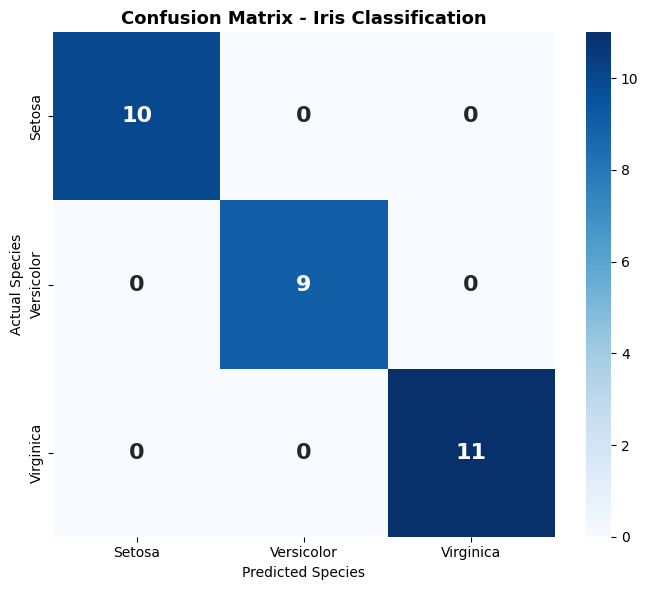

 Confusion Matrix saved!


In [21]:
print("\nClassification Report:")
print(classification_report(y_test, predictions,
      target_names=['Setosa', 'Versicolor', 'Virginica']))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'],
            annot_kws={"size": 16, "weight": "bold"})
plt.title('Confusion Matrix - Iris Classification',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.tight_layout()
plt.savefig('iris_confusion_matrix.png', dpi=150)
plt.show()
print(" Confusion Matrix saved!")

In [22]:
print("\n Model correctly classified:")
for i, species in enumerate(['Setosa', 'Versicolor', 'Virginica']):
    correct = cm[i][i]
    total   = cm[i].sum()
    print(f"   {species:<12}: {correct}/{total} correct")


 Model correctly classified:
   Setosa      : 10/10 correct
   Versicolor  : 9/9 correct
   Virginica   : 11/11 correct


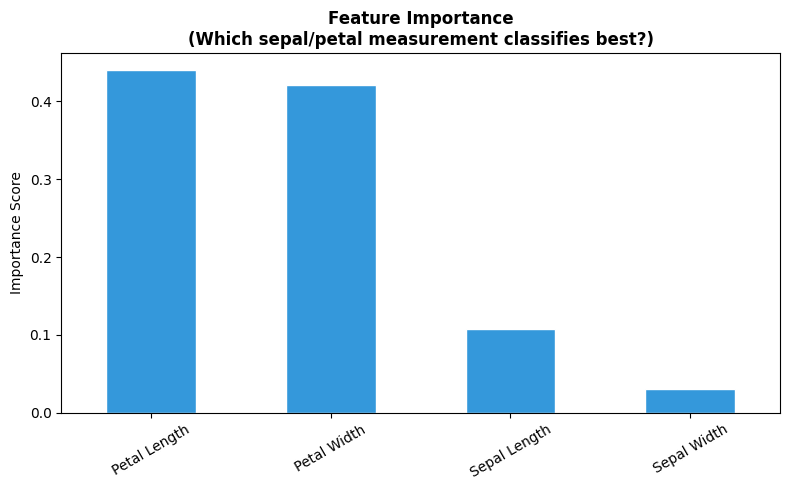


Measurement Importance (High → Low):
  Petal Length  : 0.4400  |||||||||||||||||||||
  Petal Width   : 0.4215  |||||||||||||||||||||
  Sepal Length  : 0.1081  |||||
  Sepal Width   : 0.0304  |


In [24]:
feat_imp = pd.Series(model.feature_importances_,
                     index=['Sepal Length', 'Sepal Width',
                            'Petal Length', 'Petal Width']
                     ).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar', color='#3498db', edgecolor='white')
plt.title('Feature Importance\n(Which sepal/petal measurement classifies best?)',
          fontsize=12, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('iris_feature_importance.png', dpi=150)
plt.show()

print("\nMeasurement Importance (High → Low):")
for feat, score in feat_imp.items():
    bar = '|' * int(score * 50)
    print(f"  {feat:<14}: {score:.4f}  {bar}")

In [25]:
new_flowers = pd.DataFrame({
    'sepal length (cm)': [5.1,  6.5,  6.3,  4.7,  7.0 ],
    'sepal width (cm)' : [3.5,  3.0,  2.5,  3.2,  3.2 ],
    'petal length (cm)': [1.4,  5.5,  5.0,  1.3,  4.7 ],
    'petal width (cm)' : [0.2,  1.8,  1.9,  0.2,  1.4 ],
})

species_map = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}

preds = model.predict(new_flowers)
probs = model.predict_proba(new_flowers)

print(f"\n{'Sepal(LxW)':<14} {'Petal(LxW)':<14} {'Predicted Species':<20} Confidence")
print("-" * 70)
for i, (pred, prob) in enumerate(zip(preds, probs)):
    sl = new_flowers['sepal length (cm)'].iloc[i]
    sw = new_flowers['sepal width (cm)'].iloc[i]
    pl = new_flowers['petal length (cm)'].iloc[i]
    pw = new_flowers['petal width (cm)'].iloc[i]
    sepal = f"{sl}x{sw}"
    petal = f"{pl}x{pw}"
    species = species_map[pred]
    print(f"{sepal:<14} {petal:<14} {species:<20} {prob[pred]*100:.1f}%")


Sepal(LxW)     Petal(LxW)     Predicted Species    Confidence
----------------------------------------------------------------------
5.1x3.5        1.4x0.2        Setosa               100.0%
6.5x3.0        5.5x1.8        Virginica            100.0%
6.3x2.5        5.0x1.9        Virginica            98.0%
4.7x3.2        1.3x0.2        Setosa               100.0%
7.0x3.2        4.7x1.4        Versicolor           100.0%
